In [1]:
# ==========================================
# Prodigy InfoTech Internship - Task 03
# Dogs vs Cats Classification using SVM
# ==========================================

In [3]:
!pip install opencv-python


  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


In [1]:
import cv2

print(cv2.__version__)

4.13.0


In [2]:
# Step 1: Import Required Libraries

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
# Step 2: Dataset Path

DATASET_PATH = "PetImages"

In [4]:
# Step 3: Load Images

images = []
labels = []

IMG_SIZE = 64

cat_path = os.path.join(DATASET_PATH, "Cat")
dog_path = os.path.join(DATASET_PATH, "Dog")

In [5]:
# Step 4: Load Cat Images

for img_name in os.listdir(cat_path)[:1000]:

    try:
        img_path = os.path.join(cat_path, img_name)

        img = cv2.imread(img_path)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        images.append(img.flatten())

        labels.append(0)

    except:
        pass

In [2]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles/Folders:")
print(os.listdir())

if os.path.exists("PetImages"):
    print("\nInside PetImages:")
    print(os.listdir("PetImages"))
else:
    print("PetImages folder not found")

Current Folder:
C:\Users\Manjunadh

Files/Folders:
['.anaconda', '.android', '.antigravity', '.cache', '.conda', '.condarc', '.continuum', '.copilot', '.cursor', '.gemini', '.git-for-windows-updater', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.matplotlib', '.ms-ad', '.openjfx', '.qoder', '.redhat', '.rustup', '.streamlit', '.verdent', '.viminfo', '.vscode', 'anaconda new', 'APEXRISE CEO DASHBOARD', 'AppData', 'Application Data', 'bluej', 'chatbot', 'company_growth.ipynb', 'comparison.png', 'Contacts', 'Cookies', 'CursorSetup-x64-2.1.50.exe', 'customer_support_tickets.csv', 'Documents', 'Downloads', 'Favorites', 'financial_chatbot.ipynb', 'financial_data.csv', 'FUTURE_ML_01', 'Genai', 'GENAI MAIN', 'GENAI-MAIN2', 'Git-2.52.0-64-bit.exe', 'Links', 'Local Settings', 'MACHINE LEARNING', 'Mall_Customers.csv', 'manju', 'MANJU PORTFOLIO', 'manjunadh', 'MEDHA', 'Music', 'My Documents', 'NetHood', 'node-v24.12.0-x64.msi', 'NTUSER.DAT', 'ntuser.dat.LOG1',

In [3]:
import os
import cv2
import numpy as np

images = []
labels = []

IMG_SIZE = 64

cat_path = "PetImages/Cat"
dog_path = "PetImages/Dog"

# Cats
for img_name in os.listdir(cat_path)[:500]:
    try:
        img = cv2.imread(os.path.join(cat_path, img_name))

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        images.append(img.flatten())
        labels.append(0)

    except:
        pass

# Dogs
for img_name in os.listdir(dog_path)[:500]:
    try:
        img = cv2.imread(os.path.join(dog_path, img_name))

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        images.append(img.flatten())
        labels.append(1)

    except:
        pass

print("Total Images:", len(images))
print("Unique Labels:", set(labels))

Total Images: 999
Unique Labels: {0, 1}


In [4]:
from sklearn.model_selection import train_test_split

X = np.array(images)
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)
print("Classes in y_train:", np.unique(y_train))

Training Shape: (799, 12288)
Testing Shape: (200, 12288)
Classes in y_train: [0 1]


In [5]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [6]:
y_pred = svm_model.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.54


In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.52      0.52        94
           1       0.57      0.56      0.56       106

    accuracy                           0.54       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.54      0.54      0.54       200



In [9]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[49 45]
 [47 59]]


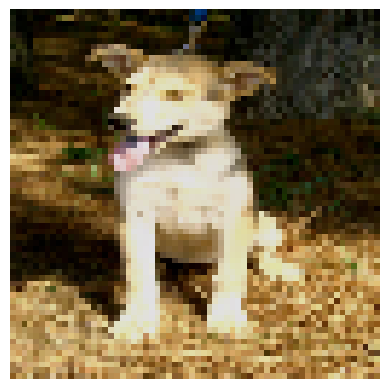

Prediction: Cat


In [10]:
import matplotlib.pyplot as plt
import cv2

sample_index = 5

sample_image = X_test[sample_index].reshape(64,64,3)

plt.imshow(cv2.cvtColor(sample_image.astype('uint8'),
                        cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print("Prediction:",
      "Dog" if y_pred[sample_index] == 1 else "Cat")